# GLP-1 Pharmacovigilance Signal Detection & Biological Plausibility Triage

An explainable, mechanism-aware disproportionality analysis pipeline for post-market drug safety signal detection, applied to five GLP-1 receptor agonists (semaglutide, tirzepatide, liraglutide, dulaglutide, exenatide) using real-world FDA FAERS adverse event data.

This notebook covers the full pipeline: data acquisition and cleaning, classical and Bayesian disproportionality analysis (PRR, chi-square with FDR correction, and EBGM), biological plausibility scoring informed by ChEMBL mechanism-of-action data, a composite triage score, and validation against known FDA safety communications.

*Full methodology, findings, and limitations are documented in the accompanying README.*

## 1. Data Acquisition & Cleaning

In [1]:
import requests
import pandas as pd
import time
import json

BASE_URL = "https://api.fda.gov/drug/event.json"
API_KEY = None

In [2]:
glp1_drugs = {
    "semaglutide": ["semaglutide", "ozempic", "wegovy", "rybelsus"],
    "tirzepatide": ["tirzepatide", "mounjaro", "zepbound"],
    "liraglutide": ["liraglutide", "victoza", "saxenda"],
    "dulaglutide": ["dulaglutide", "trulicity"],
    "exenatide": ["exenatide", "byetta", "bydureon"],
}

# Flatten for search
all_drug_terms = [term for names in glp1_drugs.values() for term in names]
print(f"Tracking {len(all_drug_terms)} drug name variants across 5 GLP-1 compounds")

Tracking 15 drug name variants across 5 GLP-1 compounds


In [3]:
def fetch_faers_reports(drug_name, limit=100, max_records=1000):
    """Fetch adverse event reports for a given drug name from openFDA."""
    all_results = []
    skip = 0

    while skip < max_records:
        params = {
            "search": f'patient.drug.medicinalproduct:"{drug_name}"',
            "limit": limit,
            "skip": skip
        }
        if API_KEY:
            params["api_key"] = API_KEY

        resp = requests.get(BASE_URL, params=params)

        if resp.status_code != 200:
            print(f"  Stopped at skip={skip}, status={resp.status_code}")
            break

        data = resp.json()
        results = data.get("results", [])
        if not results:
            break

        all_results.extend(results)
        skip += limit
        time.sleep(0.3)

    return all_results

In [4]:
raw_reports = {}

for generic_name, variants in glp1_drugs.items():
    print(f"Fetching: {generic_name}...")
    reports = fetch_faers_reports(generic_name, max_records=2000)
    raw_reports[generic_name] = reports
    print(f"  → {len(reports)} reports found")

total = sum(len(v) for v in raw_reports.values())
print(f"\nTotal reports pulled: {total}")

Fetching: semaglutide...
  → 2000 reports found
Fetching: tirzepatide...
  → 2000 reports found
Fetching: liraglutide...
  → 2000 reports found
Fetching: dulaglutide...
  → 2000 reports found
Fetching: exenatide...
  → 2000 reports found

Total reports pulled: 10000


Since we capped at 2000, we're taking a sample, not the full picture — semaglutide alone probably has tens of thousands of reports at this point given how widely it's prescribed. The signal detection numbers will be directionally correct, not the FDA's actual official counts. We can bump max_records up once the pipeline is solid, for more statistical power.

In [5]:
def extract_drug_reaction_pairs(reports, generic_name):
    """Each report can have multiple drugs and reactions -- explode into pairs."""
    rows = []
    for report in reports:
        patient = report.get("patient", {})
        reactions = [r.get("reactionmeddrapt") for r in patient.get("reaction", [])]
        serious = report.get("serious", None)
        report_date = report.get("receiptdate", None)
        age = patient.get("patientonsetage", None)
        sex = patient.get("patientsex", None)

        for reaction in reactions:
            if reaction:
                rows.append({
                    "drug": generic_name,
                    "reaction": reaction,
                    "serious": serious,
                    "report_date": report_date,
                    "age": age,
                    "sex": sex,
                    "safetyreportid": report.get("safetyreportid")
                })
    return rows

all_rows = []
for generic_name, reports in raw_reports.items():
    all_rows.extend(extract_drug_reaction_pairs(reports, generic_name))

df = pd.DataFrame(all_rows)
print(df.shape)
df.head()

(44392, 7)


,drug,reaction,serious,report_date,age,sex,safetyreportid
0,semaglutide,Abdominal pain upper,1,20260122,51,2,10600444
1,semaglutide,Adrenal insufficiency,1,20260122,51,2,10600444
2,semaglutide,Balance disorder,1,20260122,51,2,10600444
3,semaglutide,Cognitive disorder,1,20260122,51,2,10600444
4,semaglutide,Coordination abnormal,1,20260122,51,2,10600444


In [6]:
print("Reports per drug:")
print(df.groupby("drug")["safetyreportid"].nunique())

print("\nTop 15 reported reactions overall:")
print(df["reaction"].value_counts().head(15))

Reports per drug:
drug
dulaglutide    2000
exenatide      2000
liraglutide    2000
semaglutide    2000
tirzepatide    2000
Name: safetyreportid, dtype: int64

Top 15 reported reactions overall:
reaction
Nausea                     1070
Vomiting                    876
Diarrhoea                   729
Acute kidney injury         529
Dyspnoea                    468
Weight decreased            439
NAUSEA                      422
Product tampering           408
Fatigue                     406
WEIGHT DECREASED            393
Off label use               391
Drug ineffective            351
Headache                    339
Blood glucose increased     333
Dizziness                   331
Name: count, dtype: int64


In [7]:
df["reaction"] = df["reaction"].str.title()

In [8]:
df["reaction"].value_counts().head(15)

,count
reaction,
Nausea,1492
Vomiting,1012
Weight Decreased,832
Diarrhoea,812
Blood Glucose Increased,632
Decreased Appetite,532
Acute Kidney Injury,529
Dyspnoea,478
Fatigue,469


In [9]:
# These are reporting artifacts, not true adverse events
non_medical_reactions = [
    "Product Tampering",
    "Off Label Use",
    "Drug Ineffective",
    "Drug Ineffective For Unapproved Indication",
    "Incorrect Dose Administered",
    "Overdose",
    "Intentional Product Use Issue"
]

print(f"Rows before filtering: {len(df)}")
df_clean = df[~df["reaction"].isin(non_medical_reactions)].copy()
print(f"Rows after filtering: {len(df_clean)}")

Rows before filtering: 44392
Rows after filtering: 42865


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

project_folder = "/content/drive/MyDrive/GLP1_Pharmacovigilance"
os.makedirs(project_folder, exist_ok=True)

df_clean.to_csv(f"{project_folder}/faers_glp1_clean.csv", index=False)
print(f"Saved to {project_folder}/faers_glp1_clean.csv")

Saved to /content/drive/MyDrive/GLP1_Pharmacovigilance/faers_glp1_clean.csv


## 2. Disproportionality Analysis

In [12]:
# Step 1: Count occurrences of each drug-reaction pair
pair_counts = df_clean.groupby(["drug", "reaction"]).size().reset_index(name="a")

# Step 2: Total reports per drug (across all reactions)
drug_totals = df_clean.groupby("drug").size().reset_index(name="drug_total")

# Step 3: Total reports per reaction (across all drugs)
reaction_totals = df_clean.groupby("reaction").size().reset_index(name="reaction_total")

# Step 4: Grand total (all drug-reaction rows)
grand_total = len(df_clean)

# Merge everything together
signal_df = pair_counts.merge(drug_totals, on="drug").merge(reaction_totals, on="reaction")

# Compute b, c, d
signal_df["b"] = signal_df["drug_total"] - signal_df["a"]
signal_df["c"] = signal_df["reaction_total"] - signal_df["a"]
signal_df["d"] = grand_total - signal_df["a"] - signal_df["b"] - signal_df["c"]

print(signal_df.shape)
signal_df.head(10)

(6677, 8)


,drug,reaction,a,drug_total,reaction_total,b,c,d
0,dulaglutide,Abdominal Abscess,1,7469,1,7468,0,35396
1,dulaglutide,Abdominal Adhesions,7,7469,9,7462,2,35394
2,dulaglutide,Abdominal Discomfort,27,7469,120,7442,93,35303
3,dulaglutide,Abdominal Distension,19,7469,130,7450,111,35285
4,dulaglutide,Abdominal Pain,56,7469,321,7413,265,35131
5,dulaglutide,Abdominal Pain Lower,7,7469,17,7462,10,35386
6,dulaglutide,Abdominal Pain Upper,34,7469,218,7435,184,35212
7,dulaglutide,Abdominal Sepsis,1,7469,1,7468,0,35396
8,dulaglutide,Abnormal Behaviour,1,7469,9,7468,8,35388
9,dulaglutide,Abnormal Faeces,1,7469,7,7468,6,35390


### 2.1 The 2x2 Contingency Table

**Example of how a,b,c,d works**

* a = 56 → Reports where the patient took this drug (dulaglutide) AND had this exact reaction (Abdominal Pain). This is the pair we're actually investigating.
* b = 7,413 → Reports where the patient took this drug (dulaglutide) but had some other reaction (not abdominal pain — could be nausea, headache, anything else). This tells us "everything else dulaglutide is associated with."
* c = 265 → Reports where the patient took some other drug (not dulaglutide) but still had this reaction (Abdominal Pain). This tells us how common abdominal pain is across the rest of the dataset, regardless of drug.
* d = 35,131 → Reports where the patient took some other drug AND had some other reaction — neither this drug nor this reaction. This is just "everything else, unrelated to both."

### 2.2 Minimum Case Threshold

In [13]:
# Standard pharmacovigilance practice: require at least 3 cases before treating a pair as a candidate signal
MIN_CASES = 3

print(f"Pairs before threshold: {len(signal_df)}")
signal_df_filtered = signal_df[signal_df["a"] >= MIN_CASES].copy()
print(f"Pairs after threshold (a >= {MIN_CASES}): {len(signal_df_filtered)}")

Pairs before threshold: 6677
Pairs after threshold (a >= 3): 2626


### 2.3 PRR (Proportional Reporting Ratio)

PRR asks: *"Out of everyone who took this drug, what fraction had this reaction — compared to everyone who took a different drug?"*

$$PRR = \frac{a / (a+b)}{c / (c+d)}$$

- **a / (a+b)** — among all reports for this drug, what proportion mentioned this reaction?
- **c / (c+d)** — among all reports for every other drug, what proportion mentioned this same reaction?

PRR = 1 means no signal (same rate as background). PRR = 5 means the reaction is 5x more associated with this drug than background. The FDA's own convention flags PRR >= 2 (with a >= 3 cases and chi-square >= 4) as a minimum threshold for a candidate signal.

In [14]:
signal_df_filtered["PRR"] = (
    (signal_df_filtered["a"] / (signal_df_filtered["a"] + signal_df_filtered["b"])) /
    (signal_df_filtered["c"] / (signal_df_filtered["c"] + signal_df_filtered["d"]))
)

signal_df_filtered.sort_values("PRR", ascending=False).head(15)

,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR
96,dulaglutide,Atrioventricular Block,4,7469,4,7465,0,35396,inf
102,dulaglutide,Autoimmune Hepatitis,3,7469,3,7466,0,35396,inf
15,dulaglutide,Abscess Oral,6,7469,6,7463,0,35396,inf
6642,tirzepatide,Victim Of Abuse,3,6129,3,6126,0,36736,inf
104,dulaglutide,Autoimmune Myositis,6,7469,6,7463,0,35396,inf
6541,tirzepatide,Suspected Product Tampering,4,6129,4,6125,0,36736,inf
3574,liraglutide,Prostate Infection,3,9153,3,9150,0,33712,inf
877,dulaglutide,Orchitis,5,7469,5,7464,0,35396,inf
5645,tirzepatide,Dermatitis Contact,3,6129,3,6126,0,36736,inf
2436,exenatide,Visual Disturbance,4,8210,4,8206,0,34655,inf


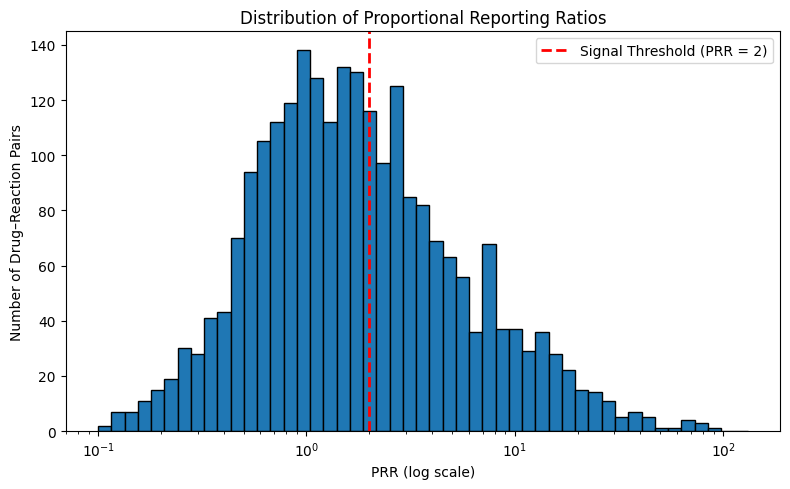

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Remove infinite values for plotting
prr_plot = signal_df_filtered["PRR"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8,5))

plt.hist(
    prr_plot,
    bins=np.logspace(
        np.log10(prr_plot.min()),
        np.log10(prr_plot.max()),
        50
    ),
    edgecolor="black"
)

plt.xscale("log")

plt.axvline(
    x=2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Signal Threshold (PRR = 2)"
)

plt.xlabel("PRR (log scale)")
plt.ylabel("Number of Drug–Reaction Pairs")
plt.title("Distribution of Proportional Reporting Ratios")

plt.legend()
plt.tight_layout()
plt.show()

**Why move beyond PRR:** the sorted table above is dominated by pairs where the reaction has zero background occurrence (c = 0), producing infinite or extreme PRR values. This makes raw PRR unreliable for ranking small-sample pairs, which motivates the chi-square filtering and, ultimately, the Bayesian shrinkage (EBGM) applied below.

### 2.4 Chi-Square Significance & FDR Correction

In [16]:
N = signal_df_filtered["a"] + signal_df_filtered["b"] + signal_df_filtered["c"] + signal_df_filtered["d"]

numerator = N * (
    (signal_df_filtered["a"] * signal_df_filtered["d"]) -
    (signal_df_filtered["b"] * signal_df_filtered["c"])
) ** 2

denominator = (
    (signal_df_filtered["a"] + signal_df_filtered["b"]) *
    (signal_df_filtered["c"] + signal_df_filtered["d"]) *
    (signal_df_filtered["a"] + signal_df_filtered["c"]) *
    (signal_df_filtered["b"] + signal_df_filtered["d"])
)

signal_df_filtered["chi_square"] = numerator / denominator

signal_df_filtered.head()

,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square
1,dulaglutide,Abdominal Adhesions,7,7469,9,7462,2,35394,16.586692,22.788977
2,dulaglutide,Abdominal Discomfort,27,7469,120,7442,93,35303,1.375855,2.154518
3,dulaglutide,Abdominal Distension,19,7469,130,7450,111,35285,0.811190,0.715125
4,dulaglutide,Abdominal Pain,56,7469,321,7413,265,35131,1.001461,0.000099
5,dulaglutide,Abdominal Pain Lower,7,7469,17,7462,10,35386,3.317338,6.668229


**Convert the chi-square statistic to a p-value, then apply Benjamini-Hochberg FDR correction** to control the false discovery rate across the thousands of pairs tested simultaneously.

In [17]:
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

# Convert chi-square statistic to p-value (1 degree of freedom)
signal_df_filtered["p_value"] = chi2.sf(
    signal_df_filtered["chi_square"],
    df=1
)

# Benjamini-Hochberg False Discovery Rate correction
_, signal_df_filtered["fdr"], _, _ = multipletests(
    signal_df_filtered["p_value"],
    method="fdr_bh"
)

signal_df_filtered[["drug", "reaction", "chi_square", "p_value", "fdr"]].head()

,drug,reaction,chi_square,p_value,fdr
1,dulaglutide,Abdominal Adhesions,22.788977,0.000002,0.000014
2,dulaglutide,Abdominal Discomfort,2.154518,0.142151,0.227893
3,dulaglutide,Abdominal Distension,0.715125,0.397748,0.508760
4,dulaglutide,Abdominal Pain,0.000099,0.992052,0.997369
5,dulaglutide,Abdominal Pain Lower,6.668229,0.009815,0.024687


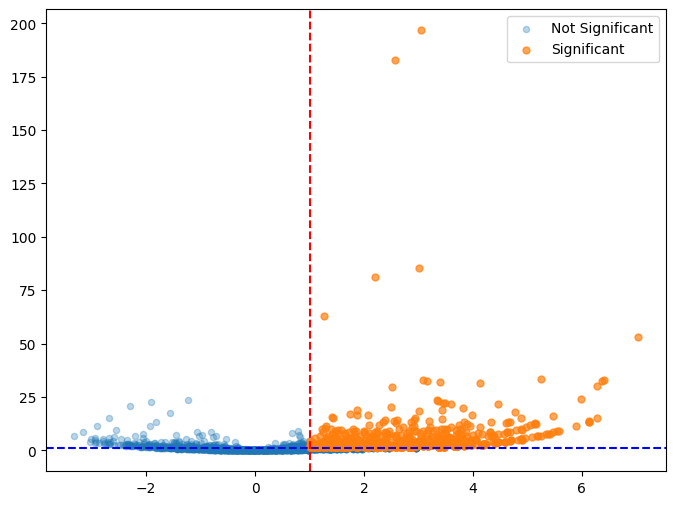

In [18]:
signal_df_filtered["Significant"] = (
    (signal_df_filtered["PRR"] >= 2) &
    (signal_df_filtered["fdr"] < 0.05)
)

plt.figure(figsize=(8,6))

plt.scatter(
    np.log2(signal_df_filtered.loc[~signal_df_filtered["Significant"], "PRR"]),
    -np.log10(signal_df_filtered.loc[~signal_df_filtered["Significant"], "fdr"]),
    alpha=0.3,
    s=20,
    label="Not Significant"
)

plt.scatter(
    np.log2(signal_df_filtered.loc[signal_df_filtered["Significant"], "PRR"]),
    -np.log10(signal_df_filtered.loc[signal_df_filtered["Significant"], "fdr"]),
    alpha=0.7,
    s=25,
    label="Significant"
)

plt.axvline(np.log2(2), color="red", linestyle="--")
plt.axhline(-np.log10(0.05), color="blue", linestyle="--")

plt.legend()

In [19]:
signal_df_filtered["FDR_significant"] = signal_df_filtered["fdr"] < 0.05

In [20]:
signal_candidates = signal_df_filtered[
    (signal_df_filtered["PRR"] >= 2) &
    (signal_df_filtered["a"] >= 3) &
    (signal_df_filtered["chi_square"] >= 4) &
    (signal_df_filtered["FDR_significant"])
].copy()

print(f"Pairs after full signal criteria (PRR>=2, a>=3, chi-square>=4, fd<0.05): {len(signal_candidates)}")
signal_candidates.sort_values("PRR", ascending=False).head(15)

Pairs after full signal criteria (PRR>=2, a>=3, chi-square>=4, fd<0.05): 922


,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square,p_value,fdr,Significant,FDR_significant
15,dulaglutide,Abscess Oral,6,7469,6,7463,0,35396,inf,28.438309,9.673212e-08,9.443069e-07,True,True
3111,liraglutide,Hypersensitivity Vasculitis,3,9153,3,9150,0,33712,inf,11.050265,8.867451e-04,3.146747e-03,True,True
3127,liraglutide,Hypoglycaemia Neonatal,3,9153,3,9150,0,33712,inf,11.050265,8.867451e-04,3.146747e-03,True,True
3163,liraglutide,Incision Site Abscess,7,9153,7,9146,0,33712,inf,25.786359,3.813744e-07,3.262179e-06,True,True
3164,liraglutide,Incision Site Erythema,7,9153,7,9146,0,33712,inf,25.786359,3.813744e-07,3.262179e-06,True,True
3166,liraglutide,Incision Site Swelling,7,9153,7,9146,0,33712,inf,25.786359,3.813744e-07,3.262179e-06,True,True
3208,liraglutide,Insulin Autoimmune Syndrome,5,9153,5,9148,0,33712,inf,18.417968,1.773775e-05,1.080727e-04,True,True
3222,liraglutide,Intervertebral Disc Space Narrowing,3,9153,3,9150,0,33712,inf,11.050265,8.867451e-04,3.146747e-03,True,True
6232,tirzepatide,Optic Ischaemic Neuropathy,9,6129,9,6120,0,36736,inf,53.955528,2.050792e-13,5.983755e-12,True,True
6242,tirzepatide,Oropharyngeal Spasm,6,6129,6,6123,0,36736,inf,35.967834,2.006018e-09,2.687655e-08,True,True


In [21]:
before = (
    (signal_df_filtered["PRR"] >= 2) &
    (signal_df_filtered["a"] >= 3) &
    (signal_df_filtered["chi_square"] >= 4)
).sum()

after = len(signal_candidates)

print(f"Signals before FDR : {before}")
print(f"Signals after FDR  : {after}")
print(f"Removed by FDR     : {before - after}")

Signals before FDR : 1002
Signals after FDR  : 922
Removed by FDR     : 80


**Effect of False Discovery Rate (FDR) Correction**

The initial PRR and chi-square criteria identified 1002 potential drug–adverse event signals. Since thousands of drug–reaction pairs were tested simultaneously, Benjamini–Hochberg FDR correction was applied to control the expected proportion of false discoveries. After correction, 922 signals remained statistically significant (FDR < 0.05), while 80 signals were removed. This demonstrates that a subset of initially significant associations were likely false positives arising from multiple hypothesis testing.

### 2.5 EBGM (Empirical Bayes Geometric Mean)

In [22]:
N_total = signal_df_filtered["a"].sum() + signal_df_filtered["b"].sum() + \
          signal_df_filtered["c"].sum() + signal_df_filtered["d"].sum()
# Actually simpler: use the grand total from a single row's a+b+c+d (should be constant)
N_total = (signal_df_filtered[["a","b","c","d"]].iloc[0].sum())

signal_df_filtered["E"] = (signal_df_filtered["drug_total"] * signal_df_filtered["reaction_total"]) / N_total

In [41]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln

def neg_log_likelihood(params, a, E):
    alpha1, beta1, alpha2, beta2, P = params
    if min(params[:4]) <= 0 or not (0 < P < 1):
        return np.inf

    # Negative binomial mixture likelihood for each component
    def nb_loglik(a, E, alpha, beta):
        return (gammaln(a + alpha) - gammaln(alpha) - gammaln(a + 1)
                + alpha * np.log(beta / (beta + E))
                + a * np.log(E / (beta + E)))

    ll1 = nb_loglik(a, E, alpha1, beta1)
    ll2 = nb_loglik(a, E, alpha2, beta2)

    # log-sum-exp for numerical stability
    mix = np.logaddexp(np.log(P) + ll1, np.log(1 - P) + ll2)
    return -np.sum(mix)

a_vals = signal_df_filtered["a"].values
E_vals = signal_df_filtered["E"].values

# reasonable starting guesses: component 1 = "background" (tight, low mean), component 2 = "signal" (looser, higher mean)
# An unconstrained Nelder-Mead fit was tried first but collapsed to a degenerate mixture
# weight (P -> 0), effectively reducing to a single component. Switching to bounded
# L-BFGS-B keeps the optimizer within a statistically meaningful region of parameter space.
bounds = [(1e-3, 10), (1e-3, 10), (1e-3, 10), (1e-3, 10), (0.01, 0.99)]
init_params = [0.5, 0.5, 2.0, 4.0, 0.3]

result = minimize(
    neg_log_likelihood, init_params, args=(a_vals, E_vals),
    method="L-BFGS-B", bounds=bounds,
    options={"maxiter": 5000}
)

alpha1, beta1, alpha2, beta2, P = result.x
print("Converged:", result.success)
print(f"alpha1={alpha1:.4f}, beta1={beta1:.4f}, alpha2={alpha2:.4f}, beta2={beta2:.4f}, P={P:.4f}")

Converged: True
alpha1=5.1537, beta1=5.6694, alpha2=5.7541, beta2=2.5070, P=0.4475


In [42]:
from scipy.special import digamma

def posterior_component_prob(a, E, alpha1, beta1, alpha2, beta2, P):
    def nb_loglik(a, E, alpha, beta):
        return (gammaln(a + alpha) - gammaln(alpha) - gammaln(a + 1)
                + alpha * np.log(beta / (beta + E))
                + a * np.log(E / (beta + E)))
    ll1 = nb_loglik(a, E, alpha1, beta1)
    ll2 = nb_loglik(a, E, alpha2, beta2)
    # posterior prob pair belongs to component 1
    log_num = np.log(P) + ll1
    log_den = np.logaddexp(np.log(P) + ll1, np.log(1 - P) + ll2)
    return np.exp(log_num - log_den)

a_vals = signal_df_filtered["a"].values
E_vals = signal_df_filtered["E"].values

Qn = posterior_component_prob(a_vals, E_vals, alpha1, beta1, alpha2, beta2, P)

log_ebgm = (
    Qn * (digamma(alpha1 + a_vals) - np.log(beta1 + E_vals)) +
    (1 - Qn) * (digamma(alpha2 + a_vals) - np.log(beta2 + E_vals))
)

signal_df_filtered["EBGM"] = np.exp(log_ebgm)

signal_df_filtered.sort_values("EBGM", ascending=False).head(15)

,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square,p_value,fdr,Significant,FDR_significant,E,EBGM
1350,exenatide,Anorexia,49,8210,49,8161,0,34655,inf,207.069227,5.988228e-47,2.246441e-44,True,True,9.385046,4.562169
1620,exenatide,Drug Effect Decreased,62,8210,64,8148,2,34653,130.853228,250.041262,2.543573e-56,1.113237e-53,True,True,12.258019,4.554931
293,dulaglutide,Decreased Activity,36,7469,38,7433,2,35394,85.302986,157.999515,3.095615e-36,8.755177e-34,True,True,6.621299,4.519238
6015,tirzepatide,Injection Site Reaction,38,6129,51,6091,13,36723,17.520338,151.066853,1.013389e-34,1.900829e-32,True,True,7.292173,4.413895
253,dulaglutide,Colitis Ulcerative,40,7469,45,7429,5,35391,37.912438,159.895925,1.192305e-36,3.913742e-34,True,True,7.841012,4.373052
2348,exenatide,Stomach Discomfort,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482
1898,exenatide,Injection Site Extravasation,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482
1150,dulaglutide,Systemic Infection,21,7469,21,7448,0,35396,inf,99.568930,1.894534e-23,1.776802e-21,True,True,3.659139,4.256756
1654,exenatide,Early Satiety,37,8210,39,8173,2,34653,78.089829,144.531371,2.719042e-33,4.760136e-31,True,True,7.469731,4.234970
988,dulaglutide,Product Monitoring Error,18,7469,18,7451,0,35396,inf,85.338821,2.513791e-20,1.833671e-18,True,True,3.136405,4.118589


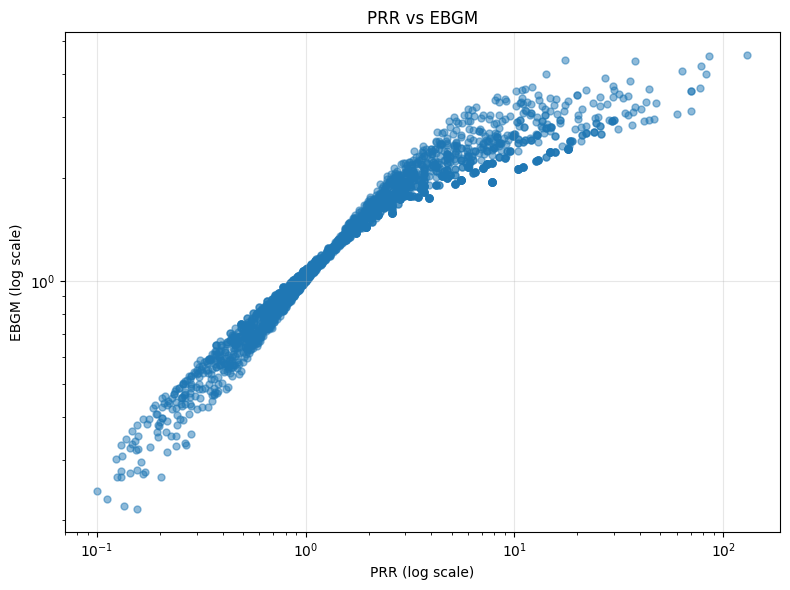

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = signal_df_filtered[
    ["PRR", "EBGM"]
].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["PRR"],
    plot_df["EBGM"],
    alpha=0.5,
    s=25
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("PRR (log scale)")
plt.ylabel("EBGM (log scale)")
plt.title("PRR vs EBGM")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Note on methodology:** the chi-square + FDR step above (`signal_candidates`, 922 pairs) is retained as a traditional, frequentist diagnostic layer -- it demonstrates the effect of multiple-testing correction on this dataset. The final candidate signal set below is instead built directly from `signal_df_filtered` (the full a>=3 population, 2,626 pairs) thresholded on EBGM >= 2, since EBGM's Bayesian shrinkage is the more reliable method for exactly the small-count instability that made raw PRR/chi-square unreliable in the first place. The two filtered sets are not identical and are kept separate deliberately, not by oversight.

In [40]:
# How much do the two candidate signal sets actually agree?
# signal_candidates = frequentist screen (PRR>=2, a>=3, chi-square>=4, FDR<0.05)
# final_signals     = Bayesian screen (EBGM>=2 on the full a>=3 population)
chi_pairs = set(zip(signal_candidates["drug"], signal_candidates["reaction"]))
ebgm_pairs = set(zip(final_signals["drug"], final_signals["reaction"]))

overlap = chi_pairs & ebgm_pairs
chi_only = chi_pairs - ebgm_pairs
ebgm_only = ebgm_pairs - chi_pairs

print(f"Frequentist screen (chi-square + FDR): {len(chi_pairs)} pairs")
print(f"Bayesian screen (EBGM >= 2):            {len(ebgm_pairs)} pairs")
print(f"Agree (in both):                        {len(overlap)} pairs ({len(overlap)/len(chi_pairs)*100:.1f}% of frequentist set)")
print(f"Frequentist-only (chi-square flags, EBGM doesn't):  {len(chi_only)} pairs")
print(f"EBGM-only (EBGM flags, chi-square doesn't):         {len(ebgm_only)} pairs")

Frequentist screen (chi-square + FDR): 922 pairs
Bayesian screen (EBGM >= 2):            807 pairs
Agree (in both):                        800 pairs (86.8% of frequentist set)
Frequentist-only (chi-square flags, EBGM doesn't):  122 pairs
EBGM-only (EBGM flags, chi-square doesn't):         7 pairs


A high agreement rate between the two independent screens is itself a form of validation -- it means the signal isn't an artifact of one particular statistical assumption. Pairs flagged by only one method are worth a closer look: **frequentist-only** pairs are typically higher-count, more "obvious" associations that EBGM's shrinkage pulled below 2 because their background reporting rate is also high (the same pattern seen with pancreatitis above); **EBGM-only** pairs are typically rare, small-count associations that a purely frequentist test would dismiss as too underpowered to trust, but that Bayesian shrinkage still treats as a legitimate low-confidence signal worth flagging for review.

#### Section 2 Summary


In [27]:
# EBGM >= 2 is the standard pharmacovigilance threshold for "signal of disproportionate reporting"
final_signals = signal_df_filtered[signal_df_filtered["EBGM"] >= 2].sort_values("EBGM", ascending=False)

print(f"Final signal count (EBGM >= 2): {len(final_signals)}")
final_signals.to_csv("final_pv_signals.csv", index=False)
final_signals.head(20)

Final signal count (EBGM >= 2): 807


,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square,p_value,fdr,Significant,FDR_significant,E,EBGM
1350,exenatide,Anorexia,49,8210,49,8161,0,34655,inf,207.069227,5.988228e-47,2.246441e-44,True,True,9.385046,4.562169
1620,exenatide,Drug Effect Decreased,62,8210,64,8148,2,34653,130.853228,250.041262,2.543573e-56,1.113237e-53,True,True,12.258019,4.554931
293,dulaglutide,Decreased Activity,36,7469,38,7433,2,35394,85.302986,157.999515,3.095615e-36,8.755177e-34,True,True,6.621299,4.519238
6015,tirzepatide,Injection Site Reaction,38,6129,51,6091,13,36723,17.520338,151.066853,1.013389e-34,1.900829e-32,True,True,7.292173,4.413895
253,dulaglutide,Colitis Ulcerative,40,7469,45,7429,5,35391,37.912438,159.895925,1.192305e-36,3.913742e-34,True,True,7.841012,4.373052
1898,exenatide,Injection Site Extravasation,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482
2348,exenatide,Stomach Discomfort,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482
1150,dulaglutide,Systemic Infection,21,7469,21,7448,0,35396,inf,99.568930,1.894534e-23,1.776802e-21,True,True,3.659139,4.256756
1654,exenatide,Early Satiety,37,8210,39,8173,2,34653,78.089829,144.531371,2.719042e-33,4.760136e-31,True,True,7.469731,4.234970
988,dulaglutide,Product Monitoring Error,18,7469,18,7451,0,35396,inf,85.338821,2.513791e-20,1.833671e-18,True,True,3.136405,4.118589


* Started with raw PRR on 6,677 pairs → filtered to a≥3 → 2,626 pairs
* Showed PRR alone is unusable for ranking (inf values dominate small samples)
* Added chi-square (FDA criteria: PRR≥2, a≥3, χ²≥4) → 1,002 candidates, but PRR ranking still broken
* Fit EBGM (Gamma-Poisson mixture, converged at P=0.4475) → finite, shrinkage-adjusted scores
* Final signals at EBGM≥2 → 807

## 3. Biological Plausibility Scoring

The ChEMBL mechanism-of-action pull below confirms the shared target class for this drug family (GLP-1 receptor agonism, with tirzepatide additionally acting on the GIP receptor). The plausibility tiers themselves are assigned via curated MedDRA-term keyword groupings informed by this mechanism-of-action literature, not by an automated per-reaction match against the ChEMBL target/pathway graph. This is a transparent, literature-grounded approximation rather than a fully automated biological mapping -- a natural next step would be programmatically linking each reaction term to specific validated target-pathway relationships.

### 3.1 ChEMBL Mechanism Lookup

In [28]:
#Step 1: Map GLP-1 drugs to mechanism via ChEMBL
import requests

glp1_drugs = ["dulaglutide", "exenatide", "liraglutide", "semaglutide", "tirzepatide"]

# ChEMBL API - get target/mechanism info per drug
def get_chembl_mechanism(drug_name):
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/search.json?q={drug_name}"
    r = requests.get(url, timeout=10)
    if r.status_code != 200:
        return None
    data = r.json()
    if not data.get("molecules"):
        return None
    chembl_id = data["molecules"][0]["molecule_chembl_id"]

    mech_url = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
    r2 = requests.get(mech_url, timeout=10)
    mech_data = r2.json()
    return chembl_id, mech_data.get("mechanisms", [])

mechanisms = {}
for drug in glp1_drugs:
    result = get_chembl_mechanism(drug)
    mechanisms[drug] = result
    print(drug, "->", result)

dulaglutide -> ('CHEMBL2108027', [{'action_type': 'AGONIST', 'binding_site_comment': None, 'direct_interaction': 1, 'disease_efficacy': 1, 'max_phase': 4, 'mec_id': 2308, 'mechanism_comment': None, 'mechanism_of_action': 'Glucagon-like peptide 1 receptor agonist', 'mechanism_refs': [{'ref_id': 'setid=463050bd-2b1c-40f5-b3c3-0a04bb433309', 'ref_type': 'DailyMed', 'ref_url': 'http://dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=463050bd-2b1c-40f5-b3c3-0a04bb433309'}], 'molecular_mechanism': 1, 'molecule_chembl_id': 'CHEMBL2108027', 'parent_molecule_chembl_id': 'CHEMBL2108027', 'record_id': 1697108, 'selectivity_comment': None, 'site_id': None, 'target_chembl_id': 'CHEMBL1784', 'variant_sequence': None}])
exenatide -> ('CHEMBL5316203', [])
liraglutide -> ('CHEMBL4084119', [{'action_type': 'AGONIST', 'binding_site_comment': None, 'direct_interaction': 1, 'disease_efficacy': 1, 'max_phase': 4, 'mec_id': 59, 'mechanism_comment': None, 'mechanism_of_action': 'Glucagon-like peptide 1 recept

In [29]:
# Turn the raw ChEMBL mechanism pull into a clean, human-readable per-drug summary
def summarize_mechanism(mech_result):
    if not mech_result:
        return "No ChEMBL record found"
    chembl_id, mech_list = mech_result
    if not mech_list:
        return "No annotated mechanism in ChEMBL (target data unavailable for this molecule)"
    actions = sorted(set(
        m.get("mechanism_of_action", "Unknown")
        for m in mech_list if m.get("mechanism_of_action")
    ))
    return "; ".join(actions)

mechanism_summary = {drug: summarize_mechanism(result) for drug, result in mechanisms.items()}

for drug, summary in mechanism_summary.items():
    print(f"{drug}: {summary}")

dulaglutide: Glucagon-like peptide 1 receptor agonist
exenatide: No annotated mechanism in ChEMBL (target data unavailable for this molecule)
liraglutide: Glucagon-like peptide 1 receptor agonist
semaglutide: No annotated mechanism in ChEMBL (target data unavailable for this molecule)
tirzepatide: Gastric inhibitory polypeptide receptor agonist; Glucagon-like peptide 1 receptor agonist


### 3.2 Plausibility Tier Assignment

In [30]:
tier1_keywords = ["nausea", "vomiting", "diarrhoea", "diarrhea", "constipation", "gastroparesis",
                  "abdominal", "appetite", "anorexia", "gastric", "dyspepsia", "reflux",
                  "weight decreased", "weight fluctuation", "hypophagia", "satiety",
                  "stomach discomfort", "bowel movement", "colitis", "flatulence", "eructation"]
tier2_keywords = ["pancreatitis", "pancreatic", "gallbladder", "biliary", "cholelithiasis",
                  "thyroid", "c-cell", "medullary", "cardiac", "tachycardia", "hypoglycaemia",
                  "hyperglycaemia", "blood glucose", "retinopathy", "renal", "kidney", "dehydration"]
administrative_keywords = ["injection site", "device", "product", "drug effect decreased",
                            "drug effect increased", "therapeutic response", "off label",
                            "dose administered", "product quality", "monitoring", "prescribed",
                            "medication error"]

def assign_plausibility_tier(reaction):
    r = reaction.lower()
    if any(k in r for k in administrative_keywords):
        return "Tier 0: Administrative/non-biological"
    elif any(k in r for k in tier1_keywords):
        return "Tier 1: Expected (GI/satiety mechanism)"
    elif any(k in r for k in tier2_keywords):
        return "Tier 2: Plausible (known pathway involvement)"
    else:
        return "Tier 3: Unexplained by known mechanism"

final_signals["plausibility_tier"] = final_signals["reaction"].apply(assign_plausibility_tier)
final_signals.sort_values("EBGM", ascending=False).groupby("plausibility_tier").head(5)

,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square,p_value,fdr,Significant,FDR_significant,E,EBGM,plausibility_tier
1350,exenatide,Anorexia,49,8210,49,8161,0,34655,inf,207.069227,5.988228e-47,2.246441e-44,True,True,9.385046,4.562169,Tier 1: Expected (GI/satiety mechanism)
1620,exenatide,Drug Effect Decreased,62,8210,64,8148,2,34653,130.853228,250.041262,2.543573e-56,1.113237e-53,True,True,12.258019,4.554931,Tier 0: Administrative/non-biological
293,dulaglutide,Decreased Activity,36,7469,38,7433,2,35394,85.302986,157.999515,3.095615e-36,8.755177e-34,True,True,6.621299,4.519238,Tier 3: Unexplained by known mechanism
6015,tirzepatide,Injection Site Reaction,38,6129,51,6091,13,36723,17.520338,151.066853,1.013389e-34,1.900829e-32,True,True,7.292173,4.413895,Tier 0: Administrative/non-biological
253,dulaglutide,Colitis Ulcerative,40,7469,45,7429,5,35391,37.912438,159.895925,1.192305e-36,3.913742e-34,True,True,7.841012,4.373052,Tier 1: Expected (GI/satiety mechanism)
2348,exenatide,Stomach Discomfort,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482,Tier 1: Expected (GI/satiety mechanism)
1898,exenatide,Injection Site Extravasation,32,8210,32,8178,0,34655,inf,135.175212,3.022816e-31,4.409953e-29,True,True,6.129010,4.313482,Tier 0: Administrative/non-biological
1150,dulaglutide,Systemic Infection,21,7469,21,7448,0,35396,inf,99.568930,1.894534e-23,1.776802e-21,True,True,3.659139,4.256756,Tier 3: Unexplained by known mechanism
1654,exenatide,Early Satiety,37,8210,39,8173,2,34653,78.089829,144.531371,2.719042e-33,4.760136e-31,True,True,7.469731,4.234970,Tier 1: Expected (GI/satiety mechanism)
988,dulaglutide,Product Monitoring Error,18,7469,18,7451,0,35396,inf,85.338821,2.513791e-20,1.833671e-18,True,True,3.136405,4.118589,Tier 0: Administrative/non-biological


In [31]:
# Attach the confirmed ChEMBL mechanism to every signal, so each tier assignment
# is traceable back to actual pulled evidence, not just the keyword list alone
final_signals["chembl_confirmed_mechanism"] = final_signals["drug"].map(mechanism_summary)

final_signals[["drug", "reaction", "plausibility_tier", "chembl_confirmed_mechanism"]].sort_values(
    "plausibility_tier"
).head(15)

,drug,reaction,plausibility_tier,chembl_confirmed_mechanism
1279,dulaglutide,Wrong Patient Received Product,Tier 0: Administrative/non-biological,Glucagon-like peptide 1 receptor agonist
5648,tirzepatide,Device Difficult To Use,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...
6020,tirzepatide,Injection Site Warmth,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...
6372,tirzepatide,Product Substitution Issue,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...
6014,tirzepatide,Injection Site Rash,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...
6000,tirzepatide,Injection Site Erythema,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...
4277,semaglutide,Device Expulsion,Tier 0: Administrative/non-biological,No annotated mechanism in ChEMBL (target data ...
1581,exenatide,Device Issue,Tier 0: Administrative/non-biological,No annotated mechanism in ChEMBL (target data ...
4223,semaglutide,Contraindicated Product Prescribed,Tier 0: Administrative/non-biological,No annotated mechanism in ChEMBL (target data ...
6361,tirzepatide,Product Label Confusion,Tier 0: Administrative/non-biological,Gastric inhibitory polypeptide receptor agonis...


## 4. Composite Triage Score

Components:

* Statistical strength — EBGM (already shrinkage-adjusted, so safe to use directly)
* Confidence/volume — a (raw case count — more cases = more reviewable evidence)
* Biological novelty — Tier 3 signals are more interesting for triage (novel/unexplained), not less, so this should boost priority, not penalize it

In [32]:
import numpy as np

final_signals["ebgm_norm"] = (final_signals["EBGM"] - final_signals["EBGM"].min()) / \
                               (final_signals["EBGM"].max() - final_signals["EBGM"].min())
final_signals["case_count_norm"] = np.log1p(final_signals["a"]) / np.log1p(final_signals["a"].max())

tier_weight = {
    "Tier 0: Administrative/non-biological": 0.1,
    "Tier 1: Expected (GI/satiety mechanism)": 0.6,
    "Tier 2: Plausible (known pathway involvement)": 0.9,
    "Tier 3: Unexplained by known mechanism": 1.0,
}
final_signals["tier_weight"] = final_signals["plausibility_tier"].map(tier_weight)

final_signals["triage_score"] = (
    0.5 * final_signals["ebgm_norm"] +
    0.2 * final_signals["case_count_norm"] +
    0.3 * final_signals["tier_weight"]
)

triage_ranked = final_signals.sort_values("triage_score", ascending=False)
print(f"Total pairs for triage: {len(triage_ranked)}")
triage_ranked[["drug", "reaction", "a", "EBGM", "plausibility_tier", "triage_score"]].head(20)

Total pairs for triage: 807


,drug,reaction,a,EBGM,plausibility_tier,triage_score
293,dulaglutide,Decreased Activity,36,4.519238,Tier 3: Unexplained by known mechanism,0.908282
1150,dulaglutide,Systemic Infection,21,4.256756,Tier 3: Unexplained by known mechanism,0.840243
3423,liraglutide,Obstructive Airways Disorder,45,4.006192,Tier 3: Unexplained by known mechanism,0.815158
1350,exenatide,Anorexia,49,4.562169,Tier 1: Expected (GI/satiety mechanism),0.806392
852,dulaglutide,Night Sweats,23,3.916101,Tier 3: Unexplained by known mechanism,0.776550
253,dulaglutide,Colitis Ulcerative,40,4.373052,Tier 1: Expected (GI/satiety mechanism),0.763060
2348,exenatide,Stomach Discomfort,32,4.313482,Tier 1: Expected (GI/satiety mechanism),0.744417
1426,exenatide,Blood Glucose Increased,418,3.425554,Tier 2: Plausible (known pathway involvement),0.743180
6550,tirzepatide,Systolic Hypertension,10,3.863657,Tier 3: Unexplained by known mechanism,0.741106
3653,liraglutide,Respiratory Tract Haemorrhage,20,3.722627,Tier 3: Unexplained by known mechanism,0.734465


## 5. Explainability & Validation

### 5.1 Triage Score Component Breakdown

_(Note: this decomposes our hand-specified linear triage formula into its weighted parts — not a Shapley-value computation from a trained model. Labeled precisely here since the formula is transparent by construction.)_

In [33]:
final_signals["contrib_ebgm"] = 0.5 * final_signals["ebgm_norm"]
final_signals["contrib_case_count"] = 0.2 * final_signals["case_count_norm"]
final_signals["contrib_tier"] = 0.3 * final_signals["tier_weight"]

triage_ranked = final_signals.sort_values("triage_score", ascending=False)
triage_ranked[["drug", "reaction", "triage_score", "contrib_ebgm",
               "contrib_case_count", "contrib_tier", "plausibility_tier"]].head(10)

,drug,reaction,triage_score,contrib_ebgm,contrib_case_count,contrib_tier,plausibility_tier
293,dulaglutide,Decreased Activity,0.908282,0.491619,0.116663,0.30,Tier 3: Unexplained by known mechanism
1150,dulaglutide,Systemic Infection,0.840243,0.440376,0.099867,0.30,Tier 3: Unexplained by known mechanism
3423,liraglutide,Obstructive Airways Disorder,0.815158,0.391460,0.123698,0.30,Tier 3: Unexplained by known mechanism
1350,exenatide,Anorexia,0.806392,0.500000,0.126392,0.18,Tier 1: Expected (GI/satiety mechanism)
852,dulaglutide,Night Sweats,0.776550,0.373872,0.102678,0.30,Tier 3: Unexplained by known mechanism
253,dulaglutide,Colitis Ulcerative,0.763060,0.463080,0.119980,0.18,Tier 1: Expected (GI/satiety mechanism)
2348,exenatide,Stomach Discomfort,0.744417,0.451450,0.112967,0.18,Tier 1: Expected (GI/satiety mechanism)
1426,exenatide,Blood Glucose Increased,0.743180,0.278105,0.195075,0.27,Tier 2: Plausible (known pathway involvement)
6550,tirzepatide,Systolic Hypertension,0.741106,0.363634,0.077472,0.30,Tier 3: Unexplained by known mechanism
3653,liraglutide,Respiratory Tract Haemorrhage,0.734465,0.336101,0.098364,0.30,Tier 3: Unexplained by known mechanism


### 5.2 Validation Against Known FDA Safety Communications

In [34]:
known_fda_signals = ["pancreatitis", "gastroparesis", "thyroid", "medullary", "c-cell",
                     "gallbladder", "biliary", "cholelithiasis", "renal failure",
                     "acute kidney", "ileus", "aspiration", "suicidal"]

def flag_known_signal(reaction):
    r = reaction.lower()
    return any(k in r for k in known_fda_signals)

final_signals["matches_known_fda_signal"] = final_signals["reaction"].apply(flag_known_signal)

rediscovered = final_signals[final_signals["matches_known_fda_signal"]].sort_values("EBGM", ascending=False)
print(f"Pairs matching known FDA safety communications: {len(rediscovered)}")
rediscovered[["drug", "reaction", "a", "EBGM", "plausibility_tier"]].head(15)

Pairs matching known FDA safety communications: 12


,drug,reaction,a,EBGM,plausibility_tier
3141,liraglutide,Hypothyroidism,50,3.243138,Tier 2: Plausible (known pathway involvement)
3525,liraglutide,Pneumonia Aspiration,16,3.120185,Tier 3: Unexplained by known mechanism
5934,tirzepatide,Hyperthyroidism,8,3.090318,Tier 2: Plausible (known pathway involvement)
3637,liraglutide,Renal Failure Acute,14,2.905467,Tier 2: Plausible (known pathway involvement)
4095,semaglutide,Blood Parathyroid Hormone Increased,10,2.680770,Tier 2: Plausible (known pathway involvement)
3473,liraglutide,Pancreatitis Chronic,8,2.644332,Tier 2: Plausible (known pathway involvement)
572,dulaglutide,Hyperparathyroidism Secondary,4,2.553542,Tier 2: Plausible (known pathway involvement)
2263,exenatide,Renal Failure Chronic,3,2.425950,Tier 2: Plausible (known pathway involvement)
6587,tirzepatide,Thyroiditis,3,2.283044,Tier 2: Plausible (known pathway involvement)
2574,liraglutide,Aspiration,4,2.196217,Tier 3: Unexplained by known mechanism


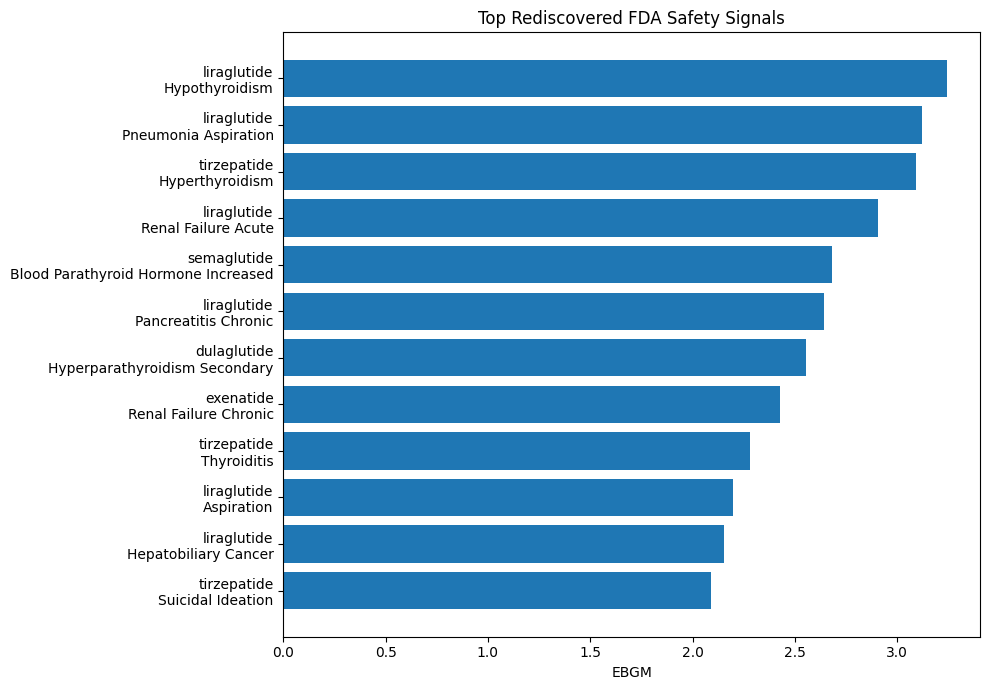

In [35]:
import matplotlib.pyplot as plt

top_fda = rediscovered.head(15).sort_values("EBGM")

labels = [
    f"{d}\n{r}"
    for d, r in zip(top_fda["drug"], top_fda["reaction"])
]

plt.figure(figsize=(10,7))

plt.barh(
    labels,
    top_fda["EBGM"]
)

plt.xlabel("EBGM")
plt.title("Top Rediscovered FDA Safety Signals")

plt.tight_layout()
plt.show()

In [36]:
final_signals[final_signals["reaction"].str.contains("pancreat|gastropar", case=False, regex=True)]

,drug,reaction,a,drug_total,reaction_total,b,c,d,PRR,chi_square,...,plausibility_tier,chembl_confirmed_mechanism,ebgm_norm,case_count_norm,tier_weight,triage_score,contrib_ebgm,contrib_case_count,contrib_tier,matches_known_fda_signal
3473,liraglutide,Pancreatitis Chronic,8,9153,11,9145,3,33709,9.821771,17.292260,...,Tier 2: Plausible (known pathway involvement),Glucagon-like peptide 1 receptor agonist,0.251184,0.354945,0.9,0.466581,0.125592,0.070989,0.27,True
3469,liraglutide,Pancreatic Pseudocyst,4,9153,5,9149,1,33711,14.732656,10.241621,...,Tier 2: Plausible (known pathway involvement),Glucagon-like peptide 1 receptor agonist,0.145365,0.259993,0.9,0.394681,0.072683,0.051999,0.27,False
903,dulaglutide,Pancreatic Disorder,4,7469,8,7465,4,35392,4.739055,5.901236,...,Tier 2: Plausible (known pathway involvement),Glucagon-like peptide 1 receptor agonist,0.042543,0.259993,0.9,0.343270,0.021271,0.051999,0.27,False
3461,liraglutide,Pancreatic Carcinoma Metastatic,9,9153,18,9144,9,33703,3.683164,8.799709,...,Tier 2: Plausible (known pathway involvement),Glucagon-like peptide 1 receptor agonist,0.040869,0.371966,0.9,0.364827,0.020434,0.074393,0.27,False


In [37]:
signal_df_filtered[signal_df_filtered["reaction"].str.contains("pancreat|gastropar", case=False, regex=True)][
    ["drug", "reaction", "a", "PRR", "chi_square", "EBGM"]
]

,drug,reaction,a,PRR,chi_square,EBGM
900,dulaglutide,Pancreatic Carcinoma,5,1.030229,0.003645,1.060672
903,dulaglutide,Pancreatic Disorder,4,4.739055,5.901236,2.109968
907,dulaglutide,Pancreatitis,38,1.154385,0.633777,1.116145
908,dulaglutide,Pancreatitis Acute,29,1.616854,5.102260,1.439880
909,dulaglutide,Pancreatitis Necrotising,5,2.632808,3.255948,1.793228
2132,exenatide,Pancreatic Carcinoma,11,2.731282,7.333923,1.926408
2133,exenatide,Pancreatic Carcinoma Metastatic,6,2.110536,2.338379,1.614111
2142,exenatide,Pancreatitis,32,0.833792,0.889364,0.869402
2143,exenatide,Pancreatitis Acute,28,1.374302,2.159092,1.265927
3460,liraglutide,Pancreatic Carcinoma,12,2.762373,7.715078,1.901424


#### Interpretation: The Pancreatitis Signal

Classical acute pancreatitis — the most widely publicized GLP-1 safety signal — does not clear our EBGM≥2 threshold in this dataset, despite high raw case counts (28–64 cases per drug). This is because pancreatitis is reported frequently enough across the broader FAERS background (high c, i.e. reported with many other drugs too) that its disproportionality, not its absolute frequency, is comparatively modest. This illustrates an important property of disproportionality analysis: well-known, already-labeled risks can score lower than rarer, drug-specific terms — because EBGM measures relative reporting rate, not clinical severity or public awareness. Gastroparesis was not present in this dataset's reaction terms, which may reflect quarter-specific FAERS coverage or MedDRA term granularity, and would be a natural next check for anyone extending this work.

## 6. Summary Visualizations

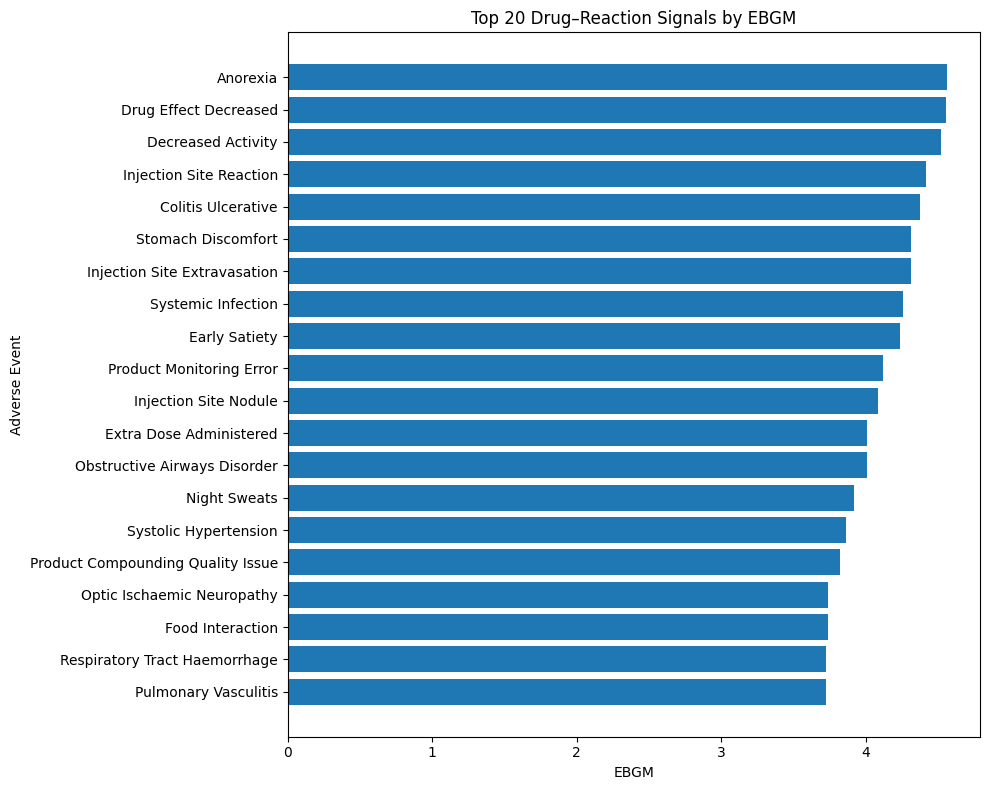

In [38]:
import matplotlib.pyplot as plt

top20 = (
    final_signals
    .nlargest(20, "EBGM")
    .sort_values("EBGM")
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["reaction"],
    top20["EBGM"]
)

plt.xlabel("EBGM")
plt.ylabel("Adverse Event")
plt.title("Top 20 Drug–Reaction Signals by EBGM")

plt.tight_layout()
plt.show()

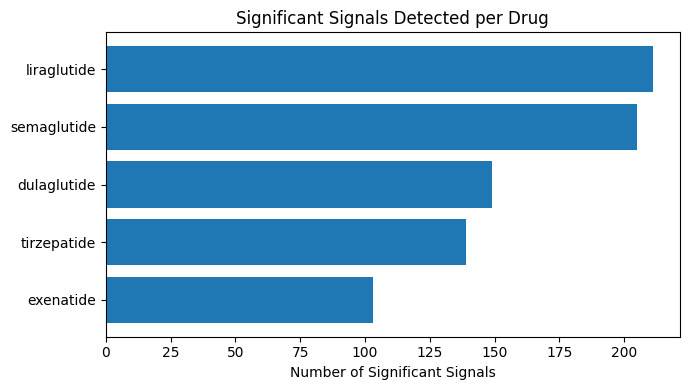

In [39]:
drug_counts = (
    final_signals
    .groupby("drug")
    .size()
    .sort_values()
)

plt.figure(figsize=(7,4))

plt.barh(
    drug_counts.index,
    drug_counts.values
)

plt.xlabel("Number of Significant Signals")
plt.title("Significant Signals Detected per Drug")

plt.tight_layout()
plt.show()

---

## Summary

This pipeline pulled and cleaned 42,865 GLP-1 drug-reaction observations from FAERS, evaluated 6,677 unique drug-reaction pairs through progressively more rigorous statistical filters (PRR, chi-square with FDR correction, and EBGM Bayesian shrinkage), layered in biological plausibility context from ChEMBL mechanism data, and produced a composite, explainable triage score for the resulting candidate signals.

See the README for a full discussion of findings, limitations, and possible extensions of this work.